## Question 1


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import grangercausalitytests

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/dataset/Data Set - Assignment 11 (VAR & ARDL) - Data Set - VAR Model.csv')

In [ ]:
df.head()

,Date,GDP Growth,Stock Index,Repo Rate,Unemployment Rate
0,3/31/1999,0.5,2028.21,11.875,9.1
1,6/30/1999,3.1,2486.96,9.125,11.9
2,9/30/1999,3.6,2096.20,9.000,8.4
3,12/31/1999,4.9,2142.97,8.750,9.5
4,3/31/2000,4.1,1681.72,8.750,9.5


In [ ]:
df.columns

Index(['Date', 'GDP Growth', 'Stock Index', 'Repo Rate', 'Unemployment Rate'], dtype='object')

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace = True)

In [ ]:
df.head()

,GDP Growth,Stock Index,Repo Rate,Unemployment Rate
Date,,,,
1999-03-31,0.5,2028.21,11.875,9.1
1999-06-30,3.1,2486.96,9.125,11.9
1999-09-30,3.6,2096.20,9.000,8.4
1999-12-31,4.9,2142.97,8.750,9.5
2000-03-31,4.1,1681.72,8.750,9.5


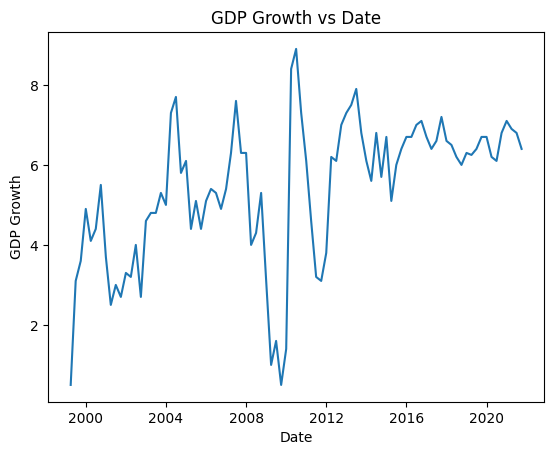

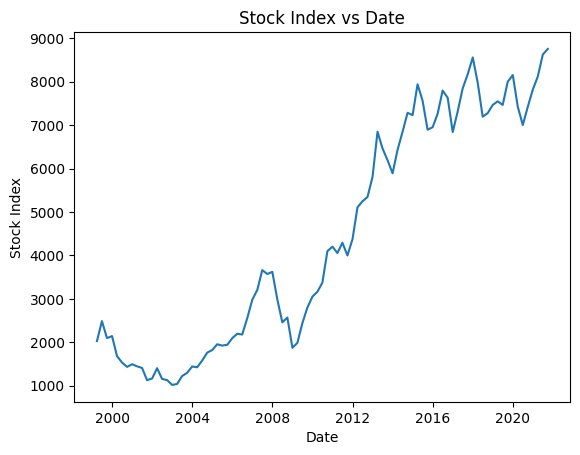

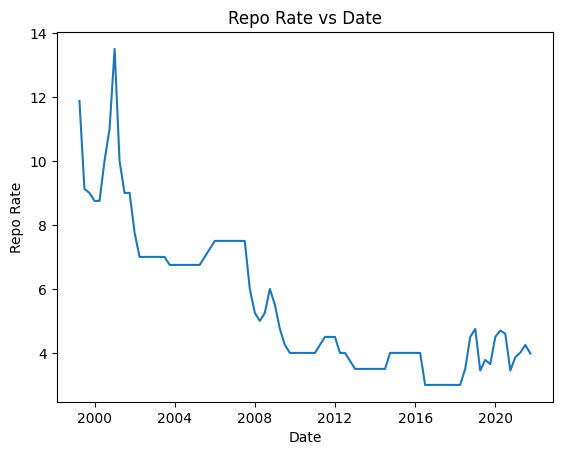

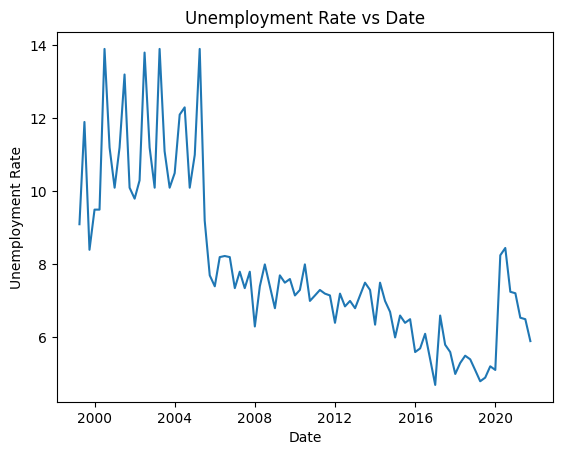

In [ ]:
for col in df.columns:
  plt.plot(df[col])
  plt.title(f'{col} vs Date')
  plt.xlabel('Date')
  plt.ylabel(f'{col}')
  plt.show()

In [ ]:
for col in df.columns:
  result = adfuller(df[col])
  if result[1]<0.05:
    print(f'{col} variable is not stationary')
  else:
    print(f'{col} variable is stationary')

GDP Growth variable is not stationary
Stock Index variable is stationary
Repo Rate variable is stationary
Unemployment Rate variable is stationary


In [ ]:
df['GDP Growth'] = df['GDP Growth'].diff()
df['GDP Growth'].dropna()

Date
1999-06-30    2.6
1999-09-30    0.5
1999-12-31    1.3
2000-03-31   -0.8
2000-06-30    0.3
             ... 
2020-09-30    0.7
2020-12-31    0.3
2021-03-31   -0.2
2021-06-30   -0.1
2021-09-30   -0.4
Name: GDP Growth, Length: 90, dtype: float64

In [ ]:
df = df.replace([np.inf, -np.inf], np.nan).dropna()

In [ ]:
result = adfuller(df['GDP Growth'])
print(f'p-value:{result[1]}')

p-value:9.589125356585001e-09


In [ ]:
mlag = 12
result = {}

for lag in range(1, mlag+1):
  model = VAR(df)
  model_fit = model.fit(lag)
  aic = model_fit.aic
  bic = model_fit.bic
  result[lag] = {'AIC':aic,'BIC':bic}

for lag, criteria in result.items():
    print(f'Lag Order: {lag}, AIC: {criteria["AIC"]}, BIC: {criteria["BIC"]}')

# Choose the lag order that minimizes AIC or BIC
best_lag = min(result, key=lambda x: result[x]['AIC'])  # Change 'AIC' to 'BIC' if you prefer BIC
print(f'Best Lag Order based on AIC: {best_lag}')

Lag Order: 1, AIC: 11.884305603326782, BIC: 12.443549731356477
Lag Order: 2, AIC: 12.095734237665658, BIC: 13.109190207224925
Lag Order: 3, AIC: 12.163942875903333, BIC: 13.637818992800327
Lag Order: 4, AIC: 12.046962317681748, BIC: 13.987609017044988
Lag Order: 5, AIC: 12.051664414260678, BIC: 14.465578597145225
Lag Order: 6, AIC: 11.96886380514493, BIC: 14.862693327577444
Lag Order: 7, AIC: 11.54435443847511, BIC: 14.924902757805295
Lag Order: 8, AIC: 11.479582035916248, BIC: 15.353813019317244
Lag Order: 9, AIC: 11.327233899823995, BIC: 15.702276799719318
Lag Order: 10, AIC: 11.600274765570731, BIC: 16.483429366652185
Lag Order: 11, AIC: 11.66167984578115, BIC: 17.06042178811107
Lag Order: 12, AIC: 11.441340068003566, BIC: 17.363326350454333
Best Lag Order based on AIC: 9


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency Q-DEC will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency Q-DEC will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency Q-DEC will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency Q-DEC will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency Q-DEC will be used.
  

In [ ]:
best_lag

9

In [ ]:
model = VAR(df)
model_fit = model.fit(best_lag)

print(model_fit.summary())

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency Q-DEC will be used.
  self._init_dates(dates, freq)


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 04, Apr, 2024
Time:                     10:16:40
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    15.7023
Nobs:                     81.0000    HQIC:                   13.0826
Log likelihood:          -770.489    FPE:                    111179.
AIC:                      11.3272    Det(Omega_mle):         24685.0
--------------------------------------------------------------------
Results for equation GDP Growth
                          coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------------
const                       -0.466424         1.891807           -0.247           0.805
L1.GDP Growth               -0.141454         0.146052           -0.969           0.333
L1.Stock Index             

In [ ]:
coefs_lag_9 = model_fit.coefs[8]

# Print coefficients for lag order L9
print("Coefficients for Lag Order L9:")
print(coefs_lag_9)

Coefficients for Lag Order L9:
[[-1.85185134e-01  5.19162997e-04 -3.40001041e-01  6.01444764e-02]
 [-5.54206654e+01 -9.73270630e-02 -9.23813777e+01  3.95287446e+01]
 [ 2.87241534e-02  1.42305864e-04 -5.10287148e-02  1.24148547e-01]
 [ 2.57025038e-01  2.17015553e-04  4.24606647e-02 -1.90780308e-01]]


In [ ]:
model_fit.coefs[8].shape

(4, 4)

In [ ]:
coefs = model_fit.coefs

# Check stability condition for each coefficient matrix
for i, coef_matrix in enumerate(coefs):
    eigenvalues = np.linalg.eigvals(coef_matrix)
    if i == 8 and all(abs(eig) < 1 for eig in eigenvalues):
        print(f"Coefficient matrix (Lag : {i+1}) is stable.")
    elif i==8:
        print(f"Coefficient matrix (Lag : {i+1}) is unstable.")

Coefficient matrix (Lag : 9) is stable.


In [ ]:
print("\nGranger Causality Test:")
for column in df.columns:
    for other_column in df.columns:
        if column != other_column:
            result = model_fit.test_causality(column, [other_column], kind='f')
            print(f"{column} and {other_column}:\n p-value =", result.pvalue,'\n')


Granger Causality Test:
GDP Growth and Stock Index:
 p-value = 0.9013235862800828 

GDP Growth and Repo Rate:
 p-value = 0.7644950963696011 

GDP Growth and Unemployment Rate:
 p-value = 0.6418678840711644 

Stock Index and GDP Growth:
 p-value = 0.652750858185938 

Stock Index and Repo Rate:
 p-value = 0.17097500847402602 

Stock Index and Unemployment Rate:
 p-value = 0.8911552776259037 

Repo Rate and GDP Growth:
 p-value = 0.8871624903095431 

Repo Rate and Stock Index:
 p-value = 0.8649300548370771 

Repo Rate and Unemployment Rate:
 p-value = 0.08667325027565993 

Unemployment Rate and GDP Growth:
 p-value = 0.10204711026518772 

Unemployment Rate and Stock Index:
 p-value = 0.3307516050186201 

Unemployment Rate and Repo Rate:
 p-value = 0.044404283876039126 



##Question 2

In [ ]:
import pandas as pd

file_path = 'assignment 11.csv'
data = pd.read_csv(file_path)

country_a_columns = ['Year', 'GDP (Bn)', 'Carbon Emission (Metric tons)', 'Energy Consumption', 'Expenditure to Protect Environment']
country_a_data = data.iloc[:, :5]
country_a_data.columns = country_a_columns

country_b_columns = ['Year', 'GDP (Bn)', 'Carbon Emission (Metric tons)', 'Energy Consumption', 'Expenditure to Protect Environment']
country_b_data = data.iloc[:, 5:10]
country_b_data.columns = country_b_columns

In [ ]:
country_a_data.head()

,Year,GDP (Bn),Carbon Emission (Metric tons),Energy Consumption,Expenditure to Protect Environment
0,1980,3317.272678,2.03,6385,70.25
1,1981,3463.234057,2.10,6979,90.25
2,1982,3583.576902,2.06,7233,114.25
3,1983,3718.162254,2.35,7850,118.65
4,1984,3908.417851,2.37,8045,150.15


In [ ]:
country_b_data.head()

,Year,GDP (Bn),Carbon Emission (Metric tons),Energy Consumption,Expenditure to Protect Environment
0,1980,1455.2541,1.05,2983.644860,30.25
1,1981,1546.4587,1.25,3261.214953,42.25
2,1982,1645.4587,1.04,3379.906542,45.12
3,1983,1785.6587,1.35,3668.224299,48.21
4,1984,1745.6541,1.64,3759.345794,60.25


In [ ]:
from statsmodels.tsa.stattools import adfuller

# Function to perform ADF test
def adf_test(series, title=''):
    result = adfuller(series, autolag='AIC')
    output = {'Test Statistic': result[0], 'p-value': result[1], 'Lags Used': result[2], 'Number of Observations Used': result[3]}
    for key, value in result[4].items():
        output[f'Critical Value ({key})'] = value
    return output

# Apply ADF test on each time series for both countries
adf_results = {
    'Country A': {
        'GDP (Bn)': adf_test(country_a_data['GDP (Bn)'], 'GDP (Bn)'),
        'Carbon Emission (Metric tons)': adf_test(country_a_data['Carbon Emission (Metric tons)'], 'Carbon Emission (Metric tons)'),
        'Energy Consumption': adf_test(country_a_data['Energy Consumption'], 'Energy Consumption'),
        'Expenditure to Protect Environment': adf_test(country_a_data['Expenditure to Protect Environment'], 'Expenditure to Protect Environment')
    },
    'Country B': {
        'GDP (Bn)': adf_test(country_b_data['GDP (Bn)'], 'GDP (Bn)'),
        'Carbon Emission (Metric tons)': adf_test(country_b_data['Carbon Emission (Metric tons)'], 'Carbon Emission (Metric tons)'),
        'Energy Consumption': adf_test(country_b_data['Energy Consumption'], 'Energy Consumption'),
        'Expenditure to Protect Environment': adf_test(country_b_data['Expenditure to Protect Environment'], 'Expenditure to Protect Environment')
    }
}

In [ ]:
def add_stationarity_info(adf_results):
    for country in adf_results:
        for series, results in adf_results[country].items():
            # Assuming a significance level of 0.05 for stationarity
            results['Stationary'] = results['p-value'] < 0.05

add_stationarity_info(adf_results)

In [ ]:
# Converting the ADF test results to a DataFrame for better readability and presentation

# Initialize an empty list to hold the data
adf_list = []

# Iterate over the results to populate the list
for country, metrics in adf_results.items():
    for metric, values in metrics.items():
        adf_list.append([country, metric, values['Test Statistic'], values['p-value'], values['Lags Used'],
                         values['Number of Observations Used'], values['Stationary']])

# Convert the list to a DataFrame
adf_df = pd.DataFrame(adf_list, columns=['Country', 'Metric', 'Test Statistic', 'p-value', 'Lags Used',
                                         'Number of Observations Used', 'Stationary'])

adf_df

,Country,Metric,Test Statistic,p-value,Lags Used,Number of Observations Used,Stationary
0,Country A,GDP (Bn),2.776413,1.000000,2,40,False
1,Country A,Carbon Emission (Metric tons),-1.450595,0.557794,1,41,False
2,Country A,Energy Consumption,0.667314,0.989162,8,34,False
3,Country A,Expenditure to Protect Environment,0.702181,0.989881,4,38,False
4,Country B,GDP (Bn),0.396126,0.981350,0,42,False
5,Country B,Carbon Emission (Metric tons),-0.836149,0.808272,2,40,False
6,Country B,Energy Consumption,0.667314,0.989162,8,34,False
7,Country B,Expenditure to Protect Environment,3.073807,1.000000,2,40,False


# Considering time trend for given data

In [ ]:
from statsmodels.tsa.ardl import ARDL

def estimate_ardl(country_data, maxlag):
    # Define the dependent variable
    y = country_data['Carbon Emission (Metric tons)']

    # Define the independent variables
    X = country_data[['GDP (Bn)', 'Energy Consumption']]

    model = ARDL(endog=y, exog=X, lags=maxlag, trend='ct',).fit()

    return model

maxlag = 10

# Estimate the ARDL model for each country
model_country_a = estimate_ardl(country_a_data, maxlag)
model_country_b = estimate_ardl(country_b_data, maxlag)

# Output the summaries
print(model_country_a.summary())
print(model_country_b.summary())

                                    ARDL Model Results                                   
Dep. Variable:     Carbon Emission (Metric tons)   No. Observations:                   43
Model:                            ARDL(10, 0, 0)   Log Likelihood                   1.847
Method:                          Conditional MLE   S.D. of innovations              0.229
Date:                           Thu, 04 Apr 2024   AIC                             26.306
Time:                                   16:36:13   BIC                             48.753
Sample:                                       10   HQIC                            33.859
                                              43                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const                                 0.8874      0.607      1.462      0.16

These results represent the output of two ARDL models, each estimating the impact of GDP and Energy Consumption on Carbon Emissions for two different datasets (presumably for two different countries or conditions). Here's how to interpret the key elements of these results:

### Model for the First Dataset:
- **Dependent Variable:** Carbon Emission (Metric tons).
- **No. Observations:** 43, indicating the number of data points used.
- **Model:** ARDL(10, 0, 0), suggesting that the model includes up to 10 lags for the dependent variable but doesn't include lags for independent variables.
- **Coefficients:**
  - The `const` term (0.8874) is the model's intercept.
  - `trend` coefficient (-0.2153) suggests a slightly negative trend in carbon emissions over time, though it's not statistically significant (p > 0.05).
  - The lagged values of Carbon Emissions show various impacts, with some lags being statistically significant (like L1 and L9), indicating that past values of emissions are relevant for predicting current emissions.
  - For the current values, `GDP (Bn).L0` has a coefficient close to zero and isn't statistically significant, suggesting no immediate impact of GDP on Carbon Emissions. In contrast, `Energy Consumption.L0` is significant (p < 0.05), indicating a positive relationship with Carbon Emissions.

### Model for the Second Dataset:
- **Dependent Variable:** Same as the first, Carbon Emission (Metric tons).
- **Model:** Same structure, ARDL(10, 0, 0).
- **Coefficients:**
  - The `const` term (0.7564) and its significance (p < 0.05) indicate a substantial intercept term.
  - The `trend` coefficient (0.0161) is not significant, suggesting no clear trend in carbon emissions over time for this dataset.
  - Similar to the first model, the lagged values of Carbon Emissions have mixed significance. No lag terms are significantly predicting Carbon Emissions, indicating that past emissions might not be as crucial for the current level of emissions in this dataset.
  - Both `GDP (Bn).L0` and `Energy Consumption.L0` are not significant, suggesting that, in this model, current GDP and Energy Consumption are not significant predictors of Carbon Emissions.

### Comparative Insights:
- **Lagged Effects:** The first dataset shows some significant lagged effects, whereas the second does not, indicating possible differences in how historical emissions impact current emissions across the two datasets.
- **GDP and Energy Consumption:** In the first dataset, Energy Consumption is a significant predictor, while in the second, neither GDP nor Energy Consumption significantly predicts Carbon Emissions. This difference could reflect distinct economic-environmental dynamics or varying energy efficiency and carbon intensity across the datasets.

### Conclusive Remarks:
- **Impact of Energy Consumption:** The first model indicates that Energy Consumption has a significant and immediate impact on Carbon Emissions. This relationship isn't observed in the second model, suggesting contextual or structural differences between the two cases.
- **GDP's Role:** GDP does not appear to be a significant predictor in either model, which could imply that the direct link between economic scale and emissions is not evident in the time frame or with the variables considered.
- **Lagged Carbon Emissions:** The significance of lagged emissions in the first model but not in the second suggests different temporal dynamics in how emissions evolve in each context.

When interpreting these results, consider the broader socio-economic and environmental context, potential model limitations, and the need for additional data or analysis to draw more definitive conclusions.

In [ ]:
from statsmodels.tsa.stattools import grangercausalitytests

maxlag = 2
test = 'ssr_chi2test'

def perform_granger_causality_tests(data):
    print("\nGranger Causality Test: GDP -> Carbon Emission")
    granger_result_gdp = grangercausalitytests(data[['Carbon Emission (Metric tons)', 'GDP (Bn)']], maxlag=maxlag, verbose=True, addconst=True)
    print("\nGranger Causality Test: Energy Consumption -> Carbon Emission")
    granger_result_energy = grangercausalitytests(data[['Carbon Emission (Metric tons)', 'Energy Consumption']], maxlag=maxlag, verbose=True, addconst=True)

print("For Country A:")
perform_granger_causality_tests(country_a_data)

print("\nFor Country B:")
perform_granger_causality_tests(country_b_data)


For Country A:

Granger Causality Test: GDP -> Carbon Emission

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.4485  , p=0.5070  , df_denom=39, df_num=1
ssr based chi2 test:   chi2=0.4830  , p=0.4871  , df=1
likelihood ratio test: chi2=0.4802  , p=0.4883  , df=1
parameter F test:         F=0.4485  , p=0.5070  , df_denom=39, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.6559  , p=0.5251  , df_denom=36, df_num=2
ssr based chi2 test:   chi2=1.4940  , p=0.4738  , df=2
likelihood ratio test: chi2=1.4674  , p=0.4801  , df=2
parameter F test:         F=0.6559  , p=0.5251  , df_denom=36, df_num=2

Granger Causality Test: Energy Consumption -> Carbon Emission

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.6322  , p=0.4313  , df_denom=39, df_num=1
ssr based chi2 test:   chi2=0.6809  , p=0.4093  , df=1
likelihood ratio test: chi2=0.6754  , p=0.4112  , df=1
parameter F test:         F=0.6322  , p=0.4313

C:\Users\arghy\anaconda3\envs\test\lib\site-packages\statsmodels\tsa\stattools.py:1488: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
C:\Users\arghy\anaconda3\envs\test\lib\site-packages\statsmodels\tsa\stattools.py:1488: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
C:\Users\arghy\anaconda3\envs\test\lib\site-packages\statsmodels\tsa\stattools.py:1488: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
C:\Users\arghy\anaconda3\envs\test\lib\site-packages\statsmodels\tsa\stattools.py:1488: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


The Granger causality test results provide insights into whether GDP and Energy Consumption Granger-cause Carbon Emission in your two datasets. Here's a breakdown of how to interpret these results:

### For Country A:

**GDP -> Carbon Emission:**
- At lag 1, the F-test and chi-square test p-values are greater than 0.05, indicating that GDP does not Granger-cause Carbon Emission at this lag.
- At lag 2, the tests also yield p-values above 0.05, reinforcing that there's no Granger causality from GDP to Carbon Emission at lag 2.

**Energy Consumption -> Carbon Emission:**
- At lag 1, similar to GDP, the p-values are above 0.05, suggesting no Granger causality from Energy Consumption to Carbon Emission at this lag.
- At lag 2, the results are consistent, with p-values again above 0.05, indicating no Granger causality at this lag either.

### For Country B:

**GDP -> Carbon Emission:**
- At lag 1, the F-test and chi-square test show p-values below 0.05, indicating a Granger causality from GDP to Carbon Emission. This suggests that past values of GDP provide significant information in predicting future values of Carbon Emission at lag 1.
- At lag 2, the p-values are above 0.05, suggesting that when considering the past two years, GDP does not Granger-cause Carbon Emission.

**Energy Consumption -> Carbon Emission:**
- At lag 1, p-values are above 0.05, indicating no Granger causality from Energy Consumption to Carbon Emission.
- At lag 2, the p-values remain above 0.05, suggesting no Granger causality at this lag as well.

### Summary of Interpretation:

- **For Country A:** There's no evidence of Granger causality from either GDP or Energy Consumption to Carbon Emission at lags 1 and 2.
- **For Country B:** GDP at lag 1 Granger-causes Carbon Emission, indicating a predictive relationship where past GDP values can help forecast future Carbon Emission levels. However, no such causality is detected from Energy Consumption.

These results imply that in Country B, economic activity (as measured by GDP) has a predictive relationship with Carbon Emissions in the short term (lag 1), but this predictive power doesn't extend to Energy Consumption or to longer lag lengths in the context of this analysis. For Country A, the economic and energy consumption variables do not have the same predictive capacity for Carbon Emissions based on the Granger causality tests.

In [ ]:
from statsmodels.tsa.ardl import ARDL

def estimate_ardl(country_data, maxlag):
    # Define the dependent variable
    y = country_data['Expenditure to Protect Environment']

    # Define the independent variables
    X = country_data[['GDP (Bn)', 'Energy Consumption']]

    model = ARDL(endog=y, exog=X, lags=maxlag, trend='ct',).fit()

    return model

maxlag = 10

# Estimate the ARDL model for each country
model_country_a = estimate_ardl(country_a_data, maxlag)
model_country_b = estimate_ardl(country_b_data, maxlag)

# Output the summaries
print(model_country_a.summary())
print(model_country_b.summary())

                                      ARDL Model Results                                      
Dep. Variable:     Expenditure to Protect Environment   No. Observations:                   43
Model:                                 ARDL(10, 0, 0)   Log Likelihood                -159.277
Method:                               Conditional MLE   S.D. of innovations             30.194
Date:                                Thu, 04 Apr 2024   AIC                            348.554
Time:                                        16:36:13   BIC                            371.002
Sample:                                            10   HQIC                           356.107
                                                   43                                         
                                             coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
const                     

These ARDL model results show the relationship between GDP and Energy Consumption on the Expenditure to Protect the Environment for two datasets, assumed to be Country A and Country B. Here's how to interpret the key elements of these results:

### Country A:

- **Dependent Variable:** Expenditure to Protect the Environment.
- **Model:** ARDL(10, 0, 0), indicating up to 10 lags for the dependent variable and no lags for the independent variables.
- **GDP (Bn).L0:** The coefficient is 0.0337, but it's not statistically significant (p=0.204), suggesting that current GDP does not have a significant immediate impact on the Expenditure to Protect the Environment.
- **Energy Consumption.L0:** The coefficient is -0.0006, also not significant (p=0.889), indicating that current Energy Consumption does not have a significant immediate impact on the Expenditure to Protect the Environment.
- **Lagged Effects:** Various lags of the Expenditure to Protect the Environment show different levels of significance, suggesting that past values have mixed influences on current expenditure levels.

### Country B:

- **GDP (Bn).L0:** The coefficient is 0.0258 and is statistically significant (p < 0.001), indicating a significant positive impact of current GDP on the Expenditure to Protect the Environment.
- **Energy Consumption.L0:** The coefficient is -0.0040, approaching significance (p=0.065), suggesting that current Energy Consumption might have a negative impact on the Expenditure to Protect the Environment, but this is not definitively confirmed at the usual 0.05 significance level.
- **Lagged Effects:** Similar to Country A, the lagged effects show varying influence, with some lags showing potential significance, indicating the historical values of expenditure might influence current levels.

### Comparative Insights:

- **Impact of GDP:** GDP has a significant positive impact on the Expenditure to Protect the Environment in Country B but not in Country A. This suggests that economic activity in Country B is more closely tied to environmental protection expenditure.
- **Impact of Energy Consumption:** Energy Consumption does not show a significant immediate impact in either country, but there is a hint of a negative relationship in Country B.
- **Temporal Dynamics:** The significance of various lags in both countries indicates that past expenditures to protect the environment influence current expenditure levels, showcasing the dynamic nature of environmental protection efforts.

### Conclusions:

- The expenditure to protect the environment in Country B is more responsive to economic changes compared to Country A.
- The role of Energy Consumption in determining environmental protection expenditure is less clear and might require further investigation.
- The significant lag effects suggest that environmental protection expenditure decisions are influenced by their own past values, indicating potential inertia or delayed responses to changes in GDP and Energy Consumption.

In [ ]:
from statsmodels.tsa.stattools import grangercausalitytests

maxlag = 2
test = 'ssr_chi2test'

def perform_granger_causality_tests(data, dependent_var, independent_vars):
    for var in independent_vars:
        print(f"\nGranger Causality Test: {var} -> {dependent_var}")
        test_result = grangercausalitytests(data[[dependent_var, var]], maxlag=maxlag, verbose=True)
#         print(test_result)

# For Country A
print("For Country A:")
k=perform_granger_causality_tests(country_a_data, 'Expenditure to Protect Environment', ['GDP (Bn)', 'Energy Consumption'])

# For Country B
print("For Country B:")
k=perform_granger_causality_tests(country_b_data, 'Expenditure to Protect Environment', ['GDP (Bn)', 'Energy Consumption'])

For Country A:

Granger Causality Test: GDP (Bn) -> Expenditure to Protect Environment

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=2.6265  , p=0.1132  , df_denom=39, df_num=1
ssr based chi2 test:   chi2=2.8286  , p=0.0926  , df=1
likelihood ratio test: chi2=2.7374  , p=0.0980  , df=1
parameter F test:         F=2.6265  , p=0.1132  , df_denom=39, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=2.8078  , p=0.0736  , df_denom=36, df_num=2
ssr based chi2 test:   chi2=6.3956  , p=0.0409  , df=2
likelihood ratio test: chi2=5.9433  , p=0.0512  , df=2
parameter F test:         F=2.8078  , p=0.0736  , df_denom=36, df_num=2

Granger Causality Test: Energy Consumption -> Expenditure to Protect Environment

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=3.7598  , p=0.0598  , df_denom=39, df_num=1
ssr based chi2 test:   chi2=4.0491  , p=0.0442  , df=1
likelihood ratio test: chi2=3.8656  , p=0.0493  , df=1
par

C:\Users\arghy\anaconda3\envs\test\lib\site-packages\statsmodels\tsa\stattools.py:1488: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
C:\Users\arghy\anaconda3\envs\test\lib\site-packages\statsmodels\tsa\stattools.py:1488: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
C:\Users\arghy\anaconda3\envs\test\lib\site-packages\statsmodels\tsa\stattools.py:1488: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
C:\Users\arghy\anaconda3\envs\test\lib\site-packages\statsmodels\tsa\stattools.py:1488: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
